<a href="https://colab.research.google.com/github/Lakuna29/DataScience-I/blob/main/Data_Wrangling_BlancoSabrina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

URBAN GROUP: CDP

**Autor/a:** Blanco Sabrina

**Curso:** Machine Learning para la Ciencia de Datos



## 1. Definición del Proyecto y Preguntas de Interés

Trabajo para un grupo gratronomico llamado Urban Group. El mismo cuenta con distintas marcas de restaurantes, un centro de produccion y franquicias de heladerias.
Yo trabajo en el centro de produccion realizando las tareas de analisis de listas de precios de los proveedores, stock de mercaderia, costos y precio de los productos que se realizan.

###  1.1. Motivación y Audiencia
* **Motivación:** En este proyecto estare conectandome a una API que me armo un compañero de trabajo en la cual se vera la información de ventas del centro de produccion a los locales.
Lo que se busca analizar es:
 - Venta a cada local: cliente
 - Comparativa de la venta a cada cliente, diferenciado por marca de restaurante
 - Venta total analizada anualmente para ver los meses en que sube y baja

Teniendo en cuenta esta informacion se puede preparar con anticipacion a los meses de mayor venta, adelantando compra de insumos, organizacion del personal.

* **Audiencia:** El analisis inicialmente esta dirigido a los que manejamos el centro de produccion. Mas adelante estaria dirigido a la gerencia.

### 1.2. Preguntas o Hipótesis Iniciales

* ¿Que local es el que mas compra?
* ¿Cuales son los meses de menor venta? Para poder analizar a que se debe
* Entre las mismas marcas ¿Cual es el que mas compra? ¿son los mismos articulos?
* ¿El clima influye? (esta solo si llego a poder conectar tambien con la api de clima por dia)


## 2. Adquisición de Datos (Data Acquisition)

1.  **Importa las librerías necesarias** (ej. `requests`, `pandas`).
2.  **Define tus credenciales de API** (si aplica). ¡Recuerda no compartir tu API Key o Tokens en un notebook público!
3.  **Realiza las llamadas a la API** para obtener los datos. Explica qué *endpoints* estás utilizando.
4.  **Convierte la respuesta JSON a un DataFrame** de Pandas.
5.  **Guarda el DataFrame crudo** en un archivo `.csv` o `.json` en tu entorno. Esto te permitirá cargar los datos directamente en futuras sesiones sin necesidad de volver a llamar a la API.

In [4]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

#Define the API endpoint URL
#endpoint /mxfac - Facturas
#Obtiene información de facturas realizadas en el centro de produccion
api_url = "http://181.171.222.208:4000/mxfac?from=2025-01-01&to=2025-07-31"

try:
    #Hacer el request
    response = requests.get(api_url)
    #Chequear si fue exitoso
    response.raise_for_status()

    #Convertir a dataframe json y dataframe
    data = response.json()
    df = pd.DataFrame(data)

    #guardar en .json
    df.to_json("facturas_julio.json", orient="records", lines=True)

    #verificacion del resultado del dataframe
    print(df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching data from API: {e}")
except ValueError as e:
    print(f"Error decoding JSON response: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

      id  numero                     fecha  cod_cli               nom_cli  \
0  19155   28771  2025-07-31T03:00:00.000Z       39       OFICINA OFICINA   
1  19154   28770  2025-07-31T03:00:00.000Z       11        DELI UNICENTER   
2  19153   28769  2025-07-31T03:00:00.000Z      100  DELI GRILLIT M MORON   
3  19152   28768  2025-07-31T03:00:00.000Z      234           MAXI FARIAS   
4  19151   28767  2025-07-31T03:00:00.000Z       78        SABRINA BLANCO   

          raz_cli           cuit      total  
0         OFICINA                 329157.84  
1         CONDIRE  30-71551039-8  358846.00  
2         CONDIRE  30-71551039-8  552307.00  
3     MAXI FARIAS                  12190.23  
4  SABRINA BLANCO                  36360.32  


## 3. Limpieza y Transformación de Datos (Data Wrangling)

### 3.1. Carga y Diagnóstico Inicial
* Carga tu dataset desde el archivo local que guardaste.
* Realiza un diagnóstico completo usando `.info()`, `.describe()`, `.shape`, y `.isnull().sum()` para entender el estado inicial de tus datos.


In [5]:
#Carga
df = pd.read_json("facturas_julio.json", orient="records", lines=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       924 non-null    int64  
 1   numero   924 non-null    int64  
 2   fecha    924 non-null    object 
 3   cod_cli  924 non-null    int64  
 4   nom_cli  924 non-null    object 
 5   raz_cli  924 non-null    object 
 6   cuit     924 non-null    object 
 7   total    924 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 57.9+ KB


No hay datos nulos


In [6]:
df.describe()

,id,numero,cod_cli,total
count,924.000000,924.000000,924.000000,9.240000e+02
mean,18693.500000,28309.500000,108.484848,1.071652e+06
std,266.880123,266.880123,103.848360,1.395065e+06
min,18232.000000,27848.000000,0.000000,-7.542758e+04
25%,18462.750000,28078.750000,8.000000,6.400953e+04
50%,18693.500000,28309.500000,78.000000,4.728359e+05
75%,18924.250000,28540.250000,196.000000,1.716389e+06
max,19155.000000,28771.000000,328.000000,9.498655e+06


### 3.2. Limpieza de Datos
* **Manejo de Valores Nulos:** Identifica columnas con datos faltantes y aplica una estrategia (eliminar, rellenar, etc.). **Justifica claramente por qué elegiste cada estrategia.**
* **Corrección de Tipos de Datos:** Convierte las columnas a sus tipos de datos correctos (ej. `pd.to_numeric()`, `pd.to_datetime()`).
* **Manejo de Filas Duplicadas:** Revisa y elimina las filas que estén completamente duplicadas.



In [7]:
#Renombre de titulos de columnas para entender que el numero es el de la factura
df.rename(columns={
    "numero": "n_factura",
     "fecha": "Fecha",
    "cod_cli": "Código cliente",
    "nom_cli": "Nombre cliente",
    "raz_cli": "Razón social",
    "monto": "Monto Factura"
  }, inplace=True)
print(df.head())

      id  n_factura                     Fecha  Código cliente  \
0  19155      28771  2025-07-31T03:00:00.000Z              39   
1  19154      28770  2025-07-31T03:00:00.000Z              11   
2  19153      28769  2025-07-31T03:00:00.000Z             100   
3  19152      28768  2025-07-31T03:00:00.000Z             234   
4  19151      28767  2025-07-31T03:00:00.000Z              78   

         Nombre cliente    Razón social           cuit      total  
0       OFICINA OFICINA         OFICINA                 329157.84  
1        DELI UNICENTER         CONDIRE  30-71551039-8  358846.00  
2  DELI GRILLIT M MORON         CONDIRE  30-71551039-8  552307.00  
3           MAXI FARIAS     MAXI FARIAS                  12190.23  
4        SABRINA BLANCO  SABRINA BLANCO                  36360.32  


In [8]:
#Tipos de datos: Fecha
df["Fecha"] = pd.to_datetime(df["Fecha"]).dt.date
df["Fecha"] = pd.to_datetime(df["Fecha"]).dt.normalize()
print(df.head())
df.info()

      id  n_factura      Fecha  Código cliente        Nombre cliente  \
0  19155      28771 2025-07-31              39       OFICINA OFICINA   
1  19154      28770 2025-07-31              11        DELI UNICENTER   
2  19153      28769 2025-07-31             100  DELI GRILLIT M MORON   
3  19152      28768 2025-07-31             234           MAXI FARIAS   
4  19151      28767 2025-07-31              78        SABRINA BLANCO   

     Razón social           cuit      total  
0         OFICINA                 329157.84  
1         CONDIRE  30-71551039-8  358846.00  
2         CONDIRE  30-71551039-8  552307.00  
3     MAXI FARIAS                  12190.23  
4  SABRINA BLANCO                  36360.32  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              924 non-null    int64         
 1   n_factura       924 non-nu

In [9]:
#Ver si hay filas duplicadas
duplicados = df.duplicated()
print(f"Filas duplicadas: {duplicados.sum()}")

Filas duplicadas: 0


In [10]:
#Eliminacion de la columna Cuit ya que no se utilizara
df = df.drop(columns=["cuit"])
print(df.head())

      id  n_factura      Fecha  Código cliente        Nombre cliente  \
0  19155      28771 2025-07-31              39       OFICINA OFICINA   
1  19154      28770 2025-07-31              11        DELI UNICENTER   
2  19153      28769 2025-07-31             100  DELI GRILLIT M MORON   
3  19152      28768 2025-07-31             234           MAXI FARIAS   
4  19151      28767 2025-07-31              78        SABRINA BLANCO   

     Razón social      total  
0         OFICINA  329157.84  
1         CONDIRE  358846.00  
2         CONDIRE  552307.00  
3     MAXI FARIAS   12190.23  
4  SABRINA BLANCO   36360.32  


In [11]:
#venta total por mes
# Crear columnas Año y Mes
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month

#Agrupar por Mes dentro del 2025
df_mensual = df.groupby("Mes")["total"].sum().reset_index()

#Diccionario de nombres de meses
meses = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}

#Mostrar en formato deseado
for _, fila in df_mensual.iterrows():
    mes_nombre = meses.get(fila["Mes"], f"Mes {fila['Mes']}")
    monto = int(round(fila["total"]))
    monto_formateado = f"{monto:,}".replace(",", ".")
    print(f"{mes_nombre}: ${monto_formateado}")

Enero: $119.927.401
Febrero: $109.686.967
Marzo: $136.220.520
Abril: $126.428.774
Mayo: $147.207.163
Junio: $155.980.418
Julio: $194.755.437


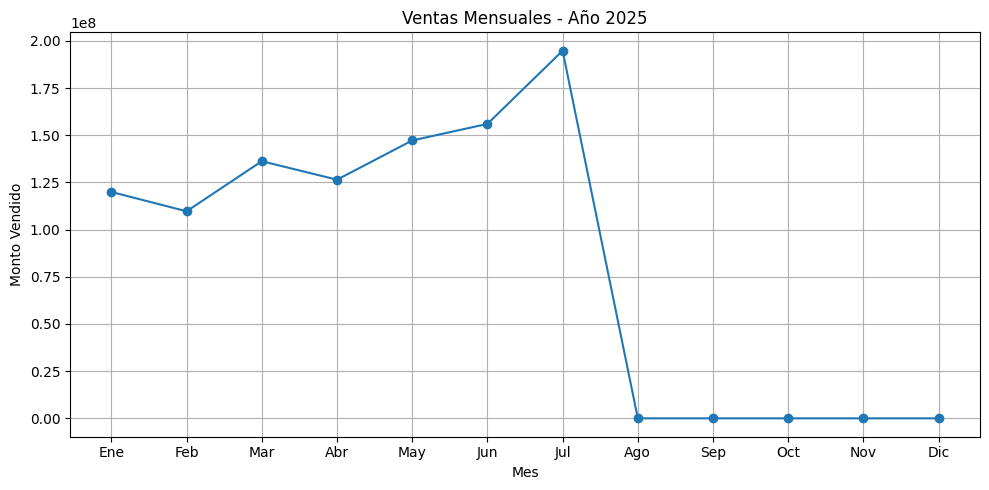

In [12]:
#grafico para ver las ventas por mes
#Extraer Año y Mes
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month

#Agrupar por mes y sumar
df_mensual = df.groupby("Mes")["total"].sum().reset_index()

#Asegurar que todos los meses estén presentes (incluso los que no tienen datos)
todos_los_meses = pd.DataFrame({"Mes": range(1, 13)})
df_mensual = todos_los_meses.merge(df_mensual, on="Mes", how="left").fillna(0)

#Nombres de meses para el eje x
meses_nombres = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

#Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(df_mensual["Mes"], df_mensual["total"], marker="o", linestyle="-")
plt.xticks(ticks=range(1, 13), labels=meses_nombres)
plt.title("Ventas Mensuales - Año 2025")
plt.xlabel("Mes")
plt.ylabel("Monto Vendido")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
#venta por razon social ordenado de mayor a menor
#Asegurarse que la columna correcta es numérica
df["total"] = pd.to_numeric(df["total"], errors="coerce")

#Agrupar por 'Razón social' y sumar
resumen_razon_social = df.groupby("Razón social")["total"].sum().reset_index()

#Ordenar de mayor a menor total facturado
resumen_razon_social = resumen_razon_social.sort_values(by="total", ascending=False)

def formatear_monto(x):
    return f"${x:,.0f}".replace(",", ".")

resumen_razon_social["Monto_formateado"] = resumen_razon_social["total"].apply(formatear_monto)
print(resumen_razon_social[["Razón social", "Monto_formateado"]])

                         Razón social Monto_formateado
40                         NORBONE SA     $205.535.738
41                           NORGRILL     $170.878.662
7                AYAM MARCELO ROBERTO     $159.178.641
21                      GENERAL RAMOS     $133.155.243
14                ESTILO AMERICANO SA      $97.569.958
10                            CONDIRE      $78.536.538
3                      ALICIA 1050 SA      $55.206.145
24  HIPODROMO ARGENTINO DE PALERMO SA      $32.952.451
52                               VMLR      $29.089.887
4            ALMACEN DEL MERCADO S.A.      $12.928.618
6               ARIZONA  HARBOUR  S.A       $2.866.437
43                            OFICINA       $2.115.185
35                    MUZZIO SANTIAGO       $1.758.671
19                            FRIOMAX       $1.093.040
47                   SEBASTIAN ARROYO         $717.920
42                     OESTE GRILL SA         $712.952
46                     SABRINA BLANCO         $579.429
48        

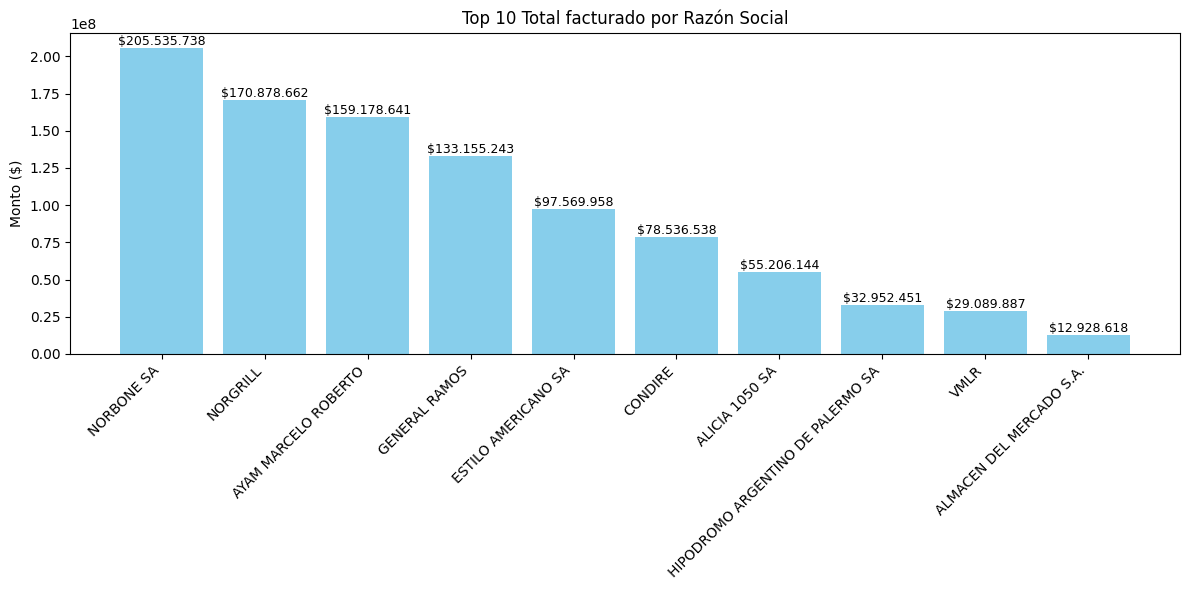

In [14]:
#Para graficar solo las primeras 10
top_10 = resumen_razon_social.head(10)

labels = top_10["Razón social"]
totales = top_10["total"]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(labels, totales, color='skyblue')

plt.xticks(rotation=45, ha='right')

for bar, monto in zip(bars, totales):
    alto = bar.get_height()
    monto_formateado = f"${int(alto):,}".replace(",", ".")
    ax.text(bar.get_x() + bar.get_width() / 2, alto, monto_formateado, ha='center', va='bottom', fontsize=9)

plt.title("Top 10 Total facturado por Razón Social")
plt.ylabel("Monto ($)")
plt.tight_layout()
plt.show()

PARTE III - ENTREGA FINAL

Eleccion de etodo de feature selection para reducir la dimencionalidad del dataset PCA


In [15]:
# Importar librerias
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#Crear features numéricas a nivel cliente
df_features = df.groupby("Código cliente").agg({"total": ["sum", "count", "mean", "max", "min"]})

#nombres de columnas
df_features.columns = ["total_facturado", "cantidad_facturas", "monto_promedio", "monto_max", "monto_min"]

#Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

#PCA: 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#DataFrame con los componentes principales
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=df_features.index)

#Revisar varianza explicada
print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print("Varianza total explicada:", pca.explained_variance_ratio_.sum())

#Combinar con las features originales
df_final = pd.concat([df_features, df_pca], axis=1)

print(df_final.head())

Varianza explicada por componente: [0.65177135 0.18153986]
Varianza total explicada: 0.8333112050497204
                total_facturado  cantidad_facturas  monto_promedio  \
Código cliente                                                       
0                  2.896440e+05                  1    2.896440e+05   
1                  1.591786e+08                 60    2.652977e+06   
6                  9.756996e+07                 96    1.016354e+06   
7                  6.443822e+04                  1    6.443822e+04   
8                  1.708787e+08                 94    1.817858e+06   

                 monto_max   monto_min       PC1       PC2  
Código cliente                                              
0                289644.00   289644.00 -0.350112  1.551771  
1               4264875.00  1108461.20  6.384873  5.085958  
6               2999453.50        0.00  3.414033 -1.670320  
7                 64438.22    64438.22 -0.863985  0.239878  
8               4680871.45   -75427.58 

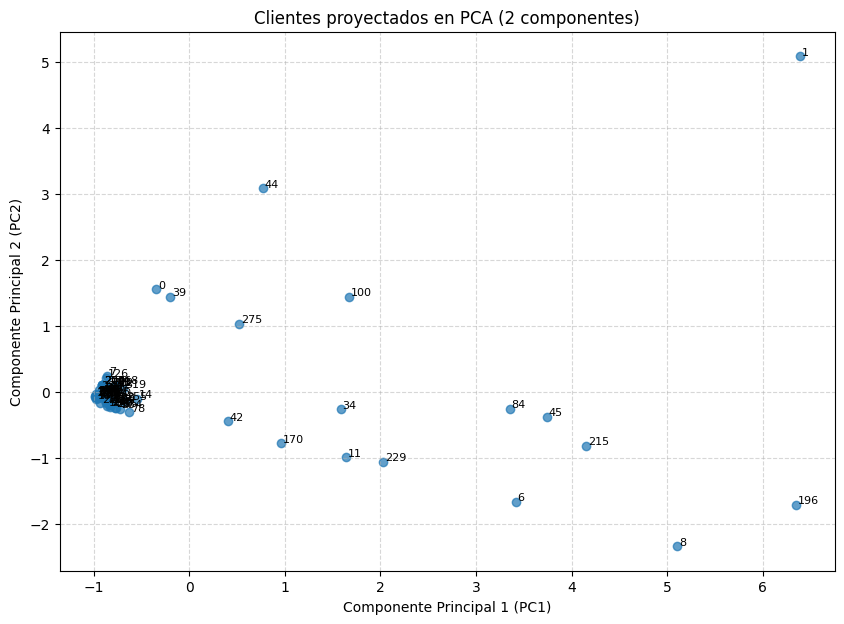

In [16]:
#Grafico PCA
plt.figure(figsize=(10, 7))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.7)

plt.title("Clientes proyectados en PCA (2 componentes)")
plt.xlabel("Componente Principal 1 (PC1)")
plt.ylabel("Componente Principal 2 (PC2)")

#agregar etiquetas de cliente
for i, cliente in enumerate(df_pca.index):
    plt.text(df_pca["PC1"].iloc[i]+0.02, df_pca["PC2"].iloc[i]+0.02, str(cliente), fontsize=8)

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

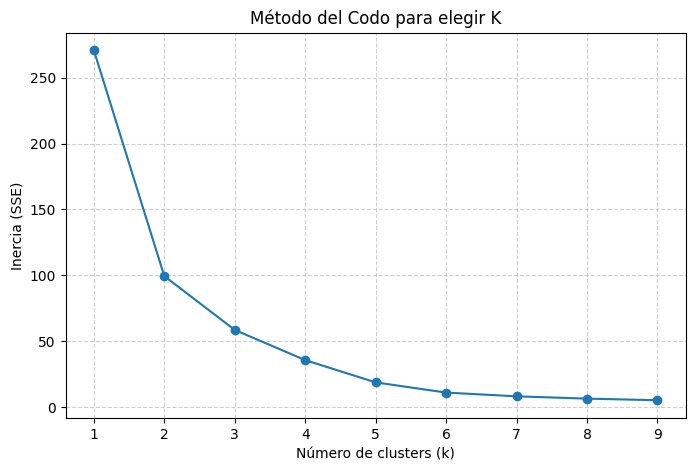

In [39]:
#Método del codo para elegir K
inercia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (SSE)")
plt.title("Método del Codo para elegir K")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


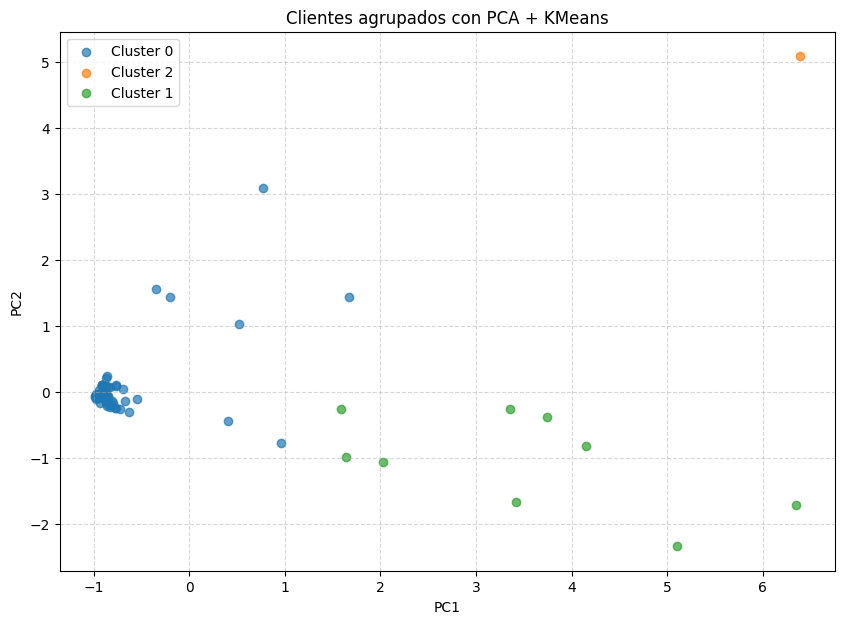

In [25]:
#Elegir un K
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pca["Cluster"] = kmeans.fit_predict(X_pca)

#Graficar clusters
plt.figure(figsize=(10,7))
for cluster in df_pca["Cluster"].unique():
    subset = df_pca[df_pca["Cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}", alpha=0.7)

plt.title("Clientes agrupados con PCA + KMeans")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [26]:
#Dataset final con features + cluster asignado
df_final = pd.concat([df_features, df_pca], axis=1)
print(df_final.head())

                total_facturado  cantidad_facturas  monto_promedio  \
Código cliente                                                       
0                  2.896440e+05                  1    2.896440e+05   
1                  1.591786e+08                 60    2.652977e+06   
6                  9.756996e+07                 96    1.016354e+06   
7                  6.443822e+04                  1    6.443822e+04   
8                  1.708787e+08                 94    1.817858e+06   

                 monto_max   monto_min       PC1       PC2  Cluster  
Código cliente                                                       
0                289644.00   289644.00 -0.350112  1.551771        0  
1               4264875.00  1108461.20  6.384873  5.085958        2  
6               2999453.50        0.00  3.414033 -1.670320        1  
7                 64438.22    64438.22 -0.863985  0.239878        0  
8               4680871.45   -75427.58  5.101906 -2.339522        1  


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

#KMeans con K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

df_features["Cluster"] = clusters

#Filtrar clusters con al menos 2 registros
counts = df_features["Cluster"].value_counts()
valid_clusters = counts[counts > 1].index
df_filtered = df_features[df_features["Cluster"].isin(valid_clusters)]

#Dataset supervisado
X = df_filtered.drop("Cluster", axis=1)
y = df_filtered["Cluster"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#Clasificador Random Forest
clf = RandomForestClassifier(random_state=42, n_estimators=200)
clf.fit(X_train, y_train)

#Predicciones y evaluación
y_pred = clf.predict(X_test)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Matriz de confusión:
[[17  0]
 [ 0  3]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00         3

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



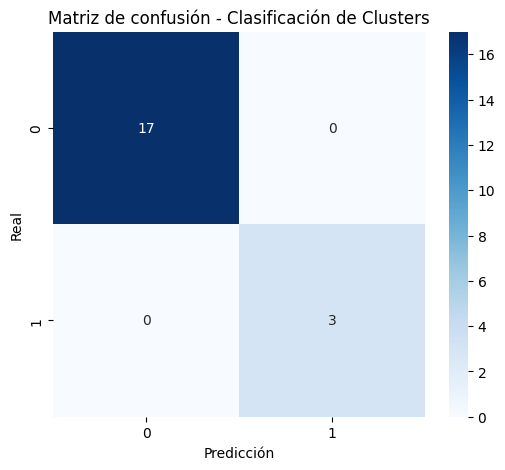

In [37]:
#Gráfico de matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)

plt.title("Matriz de confusión - Clasificación de Clusters")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [32]:
# 12. Importancia de variables
importances = pd.Series(clf.feature_importances_, index=X.columns)
print("\nImportancia de variables:")
print(importances.sort_values(ascending=False))


Importancia de variables:
total_facturado      0.366009
monto_max            0.272290
monto_promedio       0.239166
cantidad_facturas    0.106100
monto_min            0.016435
dtype: float64


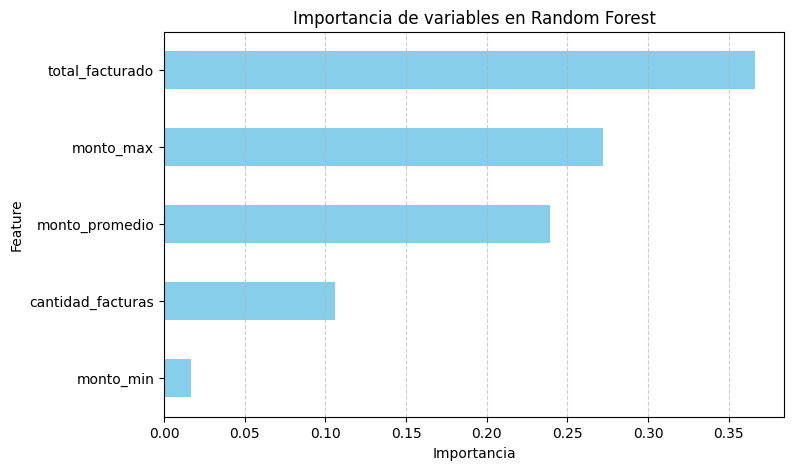

In [35]:
#Gráfico de importancia de variables
plt.figure(figsize=(8,5))
importances.sort_values().plot(kind="barh", color="skyblue")
plt.title("Importancia de variables en Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.show()
